In [1]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from dotenv import load_dotenv

load_dotenv()

c:\Users\Ashutosh Pandey\Desktop\Machine Learning\LangGraph-In-Depth\LangGraph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
sub_llm = ChatGroq(model="meta-llama/llama-prompt-guard-2-22m", temperature=0.4)

In [3]:
class sub_state(TypedDict):
    input_text: str
    translated_text: str

In [5]:
def translated_text(state: sub_state):
    prompt = """
    
    You are a good hindi translated agent,
    you job is to translate the given text into hindi
    
    text :
    {state['input_text']}
    
    """
    translated_text = sub_llm.invoke(prompt).content
    return {'translated_text': translated_text}

In [7]:
# building the subgraph
subgraph = StateGraph(sub_state)

# adding the graph nodes
subgraph.add_node("translate", translated_text)
subgraph.add_edge(START, "translate")
subgraph.add_edge("translate", END)

subgraph_node = subgraph.compile()

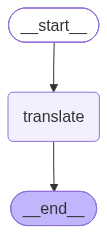

In [8]:
from IPython.display import Image
Image(subgraph_node.get_graph().draw_mermaid_png())

In [10]:
# parent graph state
class parent_state(TypedDict):
    
    question: str
    answer_eng: str
    answer_hin: str

In [11]:
parent_llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.3)

In [13]:
def generate_translation_eng(state: parent_state):
    answer = parent_llm.invoke(f"you are a english translator who translate very well with the question without anyerror! {state['question']}").content
    return {"answer_eng", answer}

In [ ]:
def generate_translation_hin(state: parent_state):
    answer = subgraph_node.invoke({"input_text": state['answer_eng']})